<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
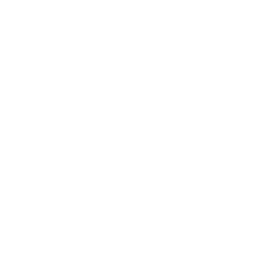
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Effektivitet af salgsrepræsentanters lægebesøg med lag-udvælgelse</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / kommerciel analyse &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Vurdér effekten af lægebesøg (detailing) og prøveudlevering på det månedlige receptvolumen for et specialpræparat ved hjælp af PROC AUTOREG. Tag højde for autokorrelerede receptmønstre med NLAG=3, og anvend BACKSTEP-optionen til automatisk at fjerne insignifikante lag-ordener. Kvantificér det marginale afkast af hvert ekstra lægebesøg for at understøtte beslutninger om feltstyrkens indsættelse og områdeinddeling.

Den syntetiske månedsserie er begrænset til 100 observationer under den nuværende kørselstilstand, hvilket er tilstrækkeligt til at genfinde effekterne af lægebesøg, prøveudlevering, formularadgang og konkurrenter med høj præcision.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.DETAILING | Månedlige recepter med mål for lægebesøg og prøveudlevering | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generér syntetiske månedlige data for lægebesøg og
   recepter for et specialiseret lægemiddelprodukt
   -------------------------------------------------------- */
data work.detailing;
    CALL streaminit(42);
    BEHOLD_VÆRDI prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    GØR month_seq = 1 TIL 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* områdetildeling roterer over 12 konsulenter */
        rep_id = cat('REP-', SKRIV_V(mod(month_seq - 1, 12) + 1, z3.));
        /* lægebesøg pr. måned */
        detail_visits = int(rand('normal', 8, 3));
        HVIS detail_visits < 0 SÅ detail_visits = 0;
        HVIS detail_visits > 20 SÅ detail_visits = 20;
        /* prøveenheder efterladt hos læger */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* formularstatus i managed care (binær) */
        formulary_status = (rand('uniform') > 0.2);
        /* pres fra konkurrentandel */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* sæsonindeks */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3)-fejlproces */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* receptmodel */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        HVIS new_rx < 0 SÅ new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        UDDATA;
    SLUT;
    FJERN prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    format obs_month monyy7.;
KØR;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Grundlæggende deskriptiv statistik for recepter og besøg
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.detailing n mean std MIN MAX;
    VARIABEL new_rx total_rx detail_visits samples_left competitor_share;
    MÆRKAT new_rx="Nye recepter (NRx)" total_rx="Recepter i alt"
           detail_visits="Lægebesøg" samples_left="Efterladte prøver"
           competitor_share="Konkurrentandel";
KØR;

                                                  The MEANS Procedure

 Variable          Label                      N            Mean        Std Dev        Minimum         Maximum
 ------------------------------------------------------------------------------------------------------------
 new_rx            Nye recepter (NRx)       100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Recepter i alt           100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Lægebesøg                100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Efterladte prøver        100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Konkurrentandel          100       0.2653000      0.1187090      0.0300000       0.5600000
 ------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


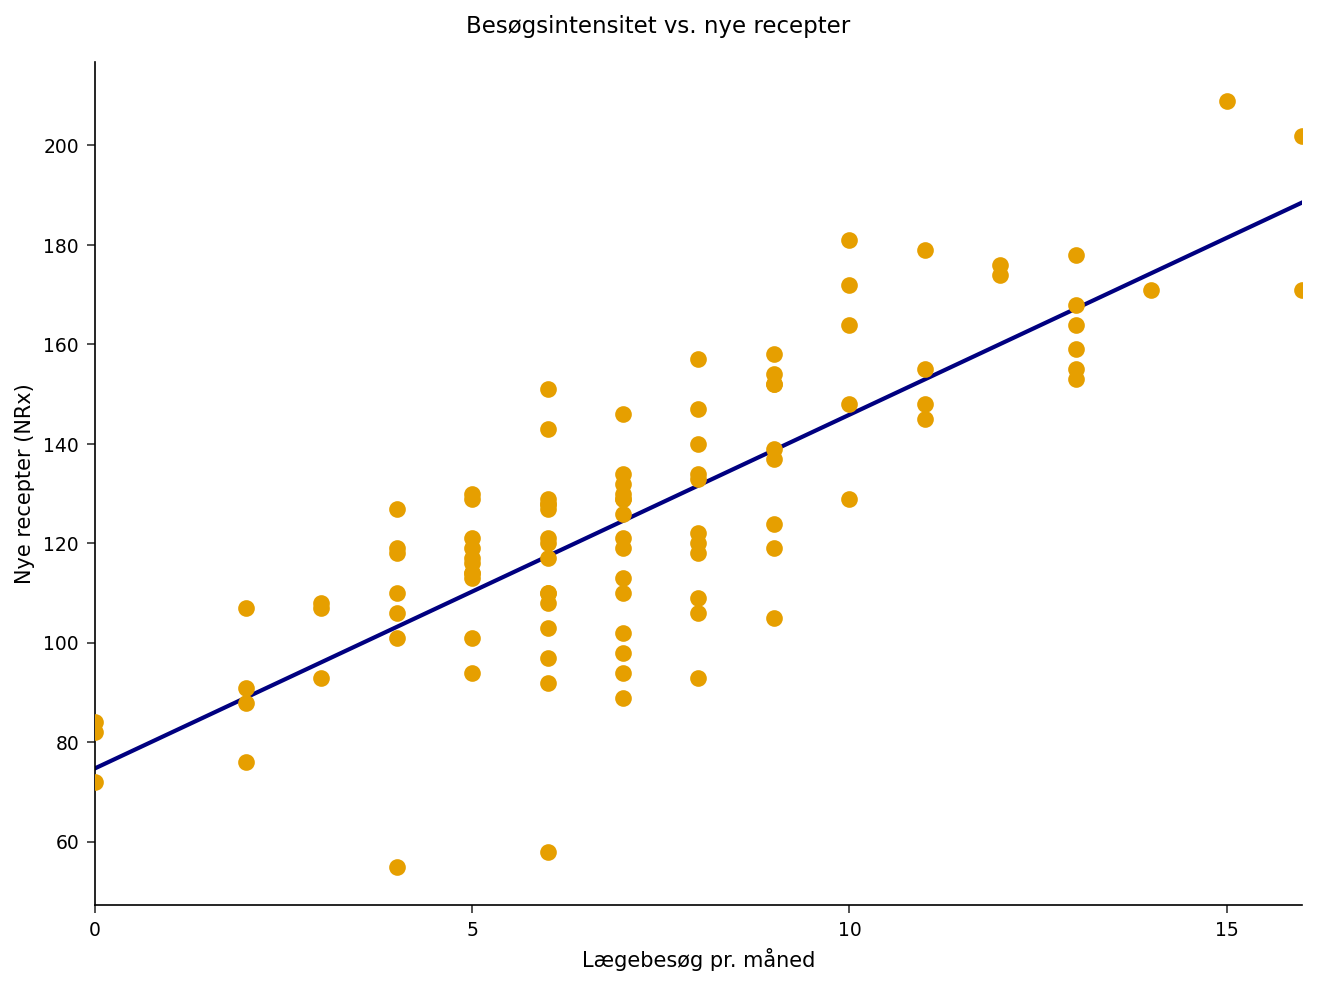

In [3]:
/* --------------------------------------------------------
   Punktplot af lægebesøg vs. nye recepter
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS MÆRKAT="Lægebesøg pr. måned";
    YAXIS MÆRKAT="Nye recepter (NRx)";
    TITEL "Besøgsintensitet vs. nye recepter";
KØR;

---

In [4]:
/* --------------------------------------------------------
   Tilpas autoregressiv model med BACKSTEP-lagudvælgelse
   NLAG=3 tester op til tre lag; BACKSTEP fjerner
   automatisk insignifikante lag
   -------------------------------------------------------- */
TITEL "Autoregressiv model: nye recepter";
PROCEDURE autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    UDDATA out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
KØR;

                                           Autoregressiv model: nye recepter                                            


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: Option TITLE changed to Autoregressiv model: nye recepter.
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Indsaml parameterestimater til ROI-beregning
   -------------------------------------------------------- */
ODS UDDATA parameterestimates=work.detail_params;

PROCEDURE autoreg data=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
KØR;

ODS UDDATA CLOSE;

                                           Autoregressiv model: nye recepter                                            


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Beregn marginal ROI pr. lægebesøg.
   ODS ParameterEstimates-datasættet gemmer Variable-
   kolonnen med store bogstaver, så filtrér på 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDURE UDSKRIV data=work.detail_params;
    HVOR variable = 'DETAIL_VISITS';
    TITEL "Marginal effekt af lægebesøg på nye recepter";
KØR;

                                      Marginal effekt af lægebesøg på nye recepter                                      

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Fortolkning

PROC AUTOREG tilpassede receptserien på 100 månedlige observationer. Hvert ekstra lægebesøg er forbundet med **+2.72 nye recepter pr. måned** (estimat 2.7158, t = 7.66, p < 0.0001), og hver enhed af prøver efterladt hos lægerne tilføjer **+1.00 NRx** (estimat 0.9997, t = 14.73), hvilket viser, at prøveudlevering forstærker, men ikke erstatter, den personlige markedsføring. Formularadgang bidrager med **+24.78 NRx pr. måned** (t = 13.83) og understreger, at adgang via managed care er en forudsætning for lægebesøgenes effektivitet, mens konkurrenternes markedsandel har en stærk negativ effekt på **-42.26 NRx pr. enhed markedsandel** (t = -6.96), hvilket markerer områder under konkurrencemæssigt pres, hvor lægebesøg alene kan være utilstrækkelige. Skæringspunktet er 69.56.

Med NLAG=3 og BACKSTEP bevarede modellen **to autoregressive lags**: lag 1 (koefficient -0.3700, t = -3.78) og lag 2 (koefficient -0.1995, t = -2.04); lag 3 blev droppet som insignifikant. Durbin-Watson-statistikken efter korrektion er **1.01**, hvilket stadig ligger et godt stykke under 2 og signalerer resterende positiv autokorrelation, så AR(2)-strukturen fanger en del, men ikke hele, den serielle afhængighed i serien. Tilpasningsstatistikker: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, log-likelihood = -342.67.

Planlægningen af feltstyrken bør fokusere på områder med gunstig formularadgang og moderat konkurrentandel, hvor det marginale afkast af hvert lægebesøg er højest.

---

In [7]:
/* --------------------------------------------------------
   Eksportér tilpassede værdier og parametre til dashboard
   for planlægning af feltstyrken
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>